In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
cwd = os.getcwd()

In [37]:
matrix_df = pd.read_table(
    cwd + "/../data/ngs_checkmate/output_output_corr_matrix.txt", index_col=0
)

In [ ]:
# Filter down to the samples of interest
diss_bulk_samples = matrix_df.columns[matrix_df.columns.str.contains("diss")]
bulk_samples = matrix_df.columns[~matrix_df.columns.str.contains("diss")]
matrix_df = matrix_df.loc[bulk_samples]
matrix_df = matrix_df[diss_bulk_samples]
# Clean up the sample names
matrix_df.index = matrix_df.index.str.replace(
    "bcftools_filtered_bulk_sample", "", regex=False
)
matrix_df.columns = matrix_df.columns.str.replace(
    "bcftools_filtered_diss_bulk_sample", "", regex=False
)
# Remove poor quality sample
matrix_df = matrix_df.drop(columns=["2507"])

In [ ]:
# Make sure the index and columns are sorted
matrix_df.index = matrix_df.index.astype(str)
sorted_df = matrix_df[sorted(matrix_df.columns)]
sorted_df = sorted_df.loc[sorted(sorted_df.index)]

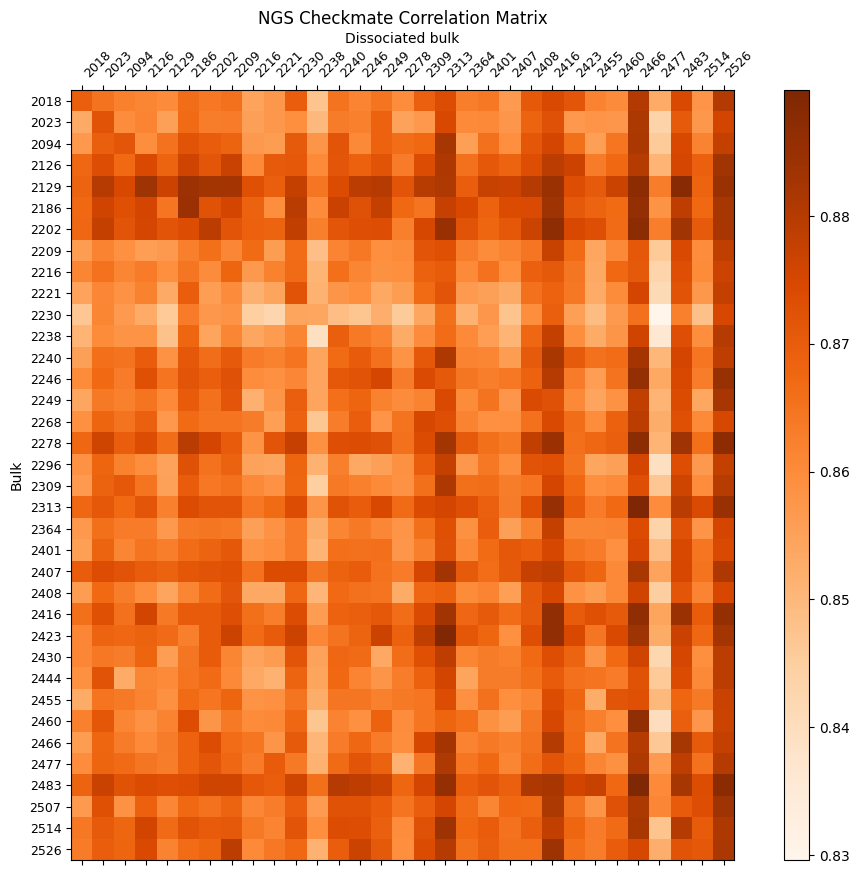

In [ ]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 10))
heatmap = ax.matshow(sorted_df, cmap="Oranges")

ax.set_xticks(np.arange(len(sorted_df.columns)))
ax.set_yticks(np.arange(len(sorted_df)))
ax.set_xticklabels(sorted_df.columns, rotation=45, ha="left", fontdict={"fontsize": 9})
ax.set_yticklabels(sorted_df.index, fontdict={"fontsize": 9})
ax.xaxis.set_label_position("top")
ax.set_xlabel("Dissociated bulk")
ax.set_ylabel("Bulk")
ax.set_title("NGS Checkmate Correlation Matrix", fontdict={"fontsize": 12})

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size=0.25, pad=0.5)
cbar = fig.colorbar(heatmap, cax=cax)

plt.show()